In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
includet("../../scripts/mm_Kl_pds.jl")

In [3]:
using ProgressMeter
using ColorSchemes
using JLD2

In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Main

In [5]:
logKs = range(-0.5, 3, 50)
lmin = 0.001
lmax = 1 - lmin
numls = 50

m = 1.
c = m
d = c * 0.5

p = 1.
DN = 0.

ks = 10 .^ range(-6, 4, 10000)

leakxs = range(LeakageScale.ltox(lmin), LeakageScale.ltox(lmax), numls)
ls = LeakageScale.l.(leakxs)
Ks = 10 .^ logKs

# @time pd_results = do_Kl_pd_run(
#     logKs, ls,
#     m, c,
#     DN, 1., p,
# );
@time pd_results = do_Kl_pd_run_scanning(
    ks,
    logKs, ls,
    m, c,
    # 0.0, 1., p;
    DN, 1., p,
    d,
    threshold=1e-9
);

 10.162695 seconds (217.51 M allocations: 28.103 GiB, 27.01% gc time, 123.71% compilation time)


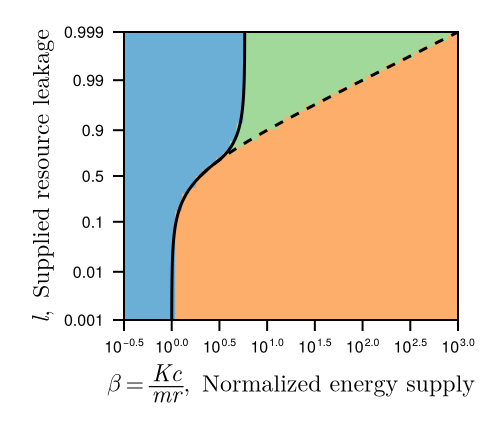

In [90]:
lticks=[0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]

fig = Figure(;
    size=(double_col_width * 0.36, (double_col_width / golden_ratio) * 0.52),
)
ax = Axis(fig[1,1],
    yticks=(LeakageScale.ltox.(lticks), string.(lticks)),
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"l,\enspace\text{Supplied resource leakage}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

heatmap!(ax, Ks, leakxs, PaperColors.mma_coloring_simple.(pd_results))

thr_leakxs = range(extrema(leakxs)..., 1000)
thr_ls = LeakageScale.l.(thr_leakxs)

extline_Ks = MinimalModelV2.fr_ext_line_K.(thr_ls, 1., 1.)
newextline_Ks = fr3_beta1.(thr_ls, d / c)
instabline_Ks = MinimalModelV2.fr_cor1_instab_line_K.(thr_ls, 1., 1., p)

lines!(ax, newextline_Ks, thr_leakxs;
    color=:black,
)
lines!(ax, instabline_Ks, thr_leakxs;
    color=:black,
    linestyle=:dash,
)

xlims!(ax, extrema(Ks))
ylims!(ax, extrema(leakxs))

# Makie.save("../../data/mm_phase_diagrams/DN1e-6_DR1e-2.pdf", fig)

fig

2.0

In [86]:
l = 0.52
gamma = 1.
# @show 4*l
# @show MinimalModelV2.fr2_beta_lb(l)
@show fr3_beta1_simple(l, gamma);

fr3_beta1_simple(l, gamma) = 2.08
